## Data loading

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import pickle

In [2]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [3]:
def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    for file in os.listdir(dataset_dir):

        # Get filename without extension
        filename = os.path.splitext(file)[0]
        filetype = os.path.splitext(file)[1]

        # Create entry if it doesn't already exist
        if filename not in data and filetype != '.pkl':
            data[filename] = {
                "image_name": None,
                "image_path": None,  
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            
            data[filename]["image_name"] = int(file.replace("bbdd_", "").replace(".jpg", ""))

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            with open(txt_path, "r", encoding="latin1") as f:
                content = f.read().strip()

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = str(lines[0])
                    data[filename]["artwork_name"] = str(lines[1])

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [4]:
df_bbdd = build_dataset(TRAIN_DIR)
print(df_bbdd.shape)
df_bbdd.head()

(287, 4)


,image_name,image_path,artist,artwork_name
0,0,data/BBDD\bbdd_00000.jpg,Victor Perez-Porros,Des-li-zan-tes
1,1,data/BBDD\bbdd_00001.jpg,Hugo Demarco,Reflecting Room
2,2,data/BBDD\bbdd_00002.jpg,None,None
3,3,data/BBDD\bbdd_00003.jpg,Edvard Munch,Youth
4,4,data/BBDD\bbdd_00004.jpg,Martin Carral,Ciclo espacial XXIV


In [5]:
df_qsd1_w1 = build_dataset(TEST_DIR)

# erase artist and artwork_name
df_qsd1_w1 = df_qsd1_w1.drop(columns=['artist','artwork_name'])

# add correspondencies as a new colum 'ground_truth'
correspondence_path = os.path.join(TEST_DIR, "gt_corresps.pkl")
with open(correspondence_path, "rb") as file:
    correspondences = pickle.load(file)

df_qsd1_w1["ground_truth"] = (df_qsd1_w1["image_name"].map(lambda idx: correspondences[idx][0]))

print(df_qsd1_w1.shape)
df_qsd1_w1.head()

(30, 3)


,image_name,image_path,ground_truth
0,0,data/qsd1_w1\00000.jpg,120
1,1,data/qsd1_w1\00001.jpg,170
2,2,data/qsd1_w1\00002.jpg,277
3,3,data/qsd1_w1\00003.jpg,227
4,4,data/qsd1_w1\00004.jpg,251


## Descriptors

In [6]:
# build the histograms 
BINS = 256
EPS = 1e-10

# OpenCV conversion code + value range of each channel (8-bit images)
COLOR_SPACES = {
    "lab":   (cv2.COLOR_BGR2LAB,   [(0, 256), (0, 256), (0, 256)]),
    "ycbcr": (cv2.COLOR_BGR2YCrCb, [(0, 256), (0, 256), (0, 256)]),  # OpenCV order: Y, Cr, Cb
    "hsv":   (cv2.COLOR_BGR2HSV,   [(0, 180), (0, 256), (0, 256)]),  # H is 0-179 in OpenCV
}

def compute_histogram(image_path, color_space, bins=BINS):
    """
    Compute a 1D histogram per channel in the given color space,
    normalize each channel (L1) and concatenate the 3 of them.

    Returns:
    np.ndarray (float32) of shape (3 * bins,), sums to 1.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    code, ranges = COLOR_SPACES[color_space]
    img = cv2.cvtColor(img, code)

    hists = []
    for ch, (low, high) in enumerate(ranges):
        h = cv2.calcHist([img], [ch], None, [high], [low, high])
        cv2.normalize(h, h, alpha=1, norm_type=cv2.NORM_L1)  # each channel sums to 1
        hists.append(h.ravel())

    # Divide by number of channels so the full histogram sums to 1
    return np.concatenate(hists)

In [7]:
CHANNEL_INFO = {
    "hsv":   (["H", "S", "V"],   ["tab:purple", "tab:green", "tab:gray"]),
    "lab":   (["L", "a", "b"],   ["tab:gray", "tab:red", "tab:blue"]),
    "ycbcr": (["Y", "Cr", "Cb"], ["tab:gray", "tab:red", "tab:blue"]),}

def plot_image_histograms(row, color_space="hsv", bins=None):
    names, colors = CHANNEL_INFO[color_space]
    ranges = COLOR_SPACES[color_space][1]
    sizes = [high - low for low, high in ranges]
    channels = np.split(row[f"hist_{color_space}"], np.cumsum(sizes)[:-1])

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    axes[0].imshow(cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Image {row['image_name']}")
    axes[0].axis("off")

    for ax, hist, (low, high), name, color in zip(axes[1:], channels, ranges, names, colors):
        sns.histplot(x=np.arange(low, high), weights=hist, bins=bins or high - low,
                     binrange=(low, high), color=color, ax=ax)
        ax.set(title=f"{color_space.upper()} - {name}", xlabel="Value", ylabel="Frequency", xlim=(low, high))

    fig.tight_layout()
    plt.show()

In [8]:
for cs in COLOR_SPACES:
    df_bbdd[f"hist_{cs}"] = df_bbdd["image_path"].apply(lambda p: compute_histogram(p, cs))

In [9]:
df_bbdd.head()

,image_name,image_path,artist,artwork_name,hist_lab,hist_ycbcr,hist_hsv
0,0,data/BBDD\bbdd_00000.jpg,Victor Perez-Porros,Des-li-zan-tes,"[0.0013478914, 0.0076686703, 0.01111962, 0.009...","[0.0004882964, 0.0027866736, 0.0049999612, 0.0...","[0.022291454, 0.012597079, 0.015620649, 0.0165..."
1,1,data/BBDD\bbdd_00001.jpg,Hugo Demarco,Reflecting Room,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2,data/BBDD\bbdd_00002.jpg,None,None,"[0.0030003206, 0.015843296, 0.032053042, 0.017...","[0.0012940314, 0.0040996745, 0.012167331, 0.01...","[0.046167146, 0.0, 9.733864e-05, 0.00024048371..."
3,3,data/BBDD\bbdd_00003.jpg,Edvard Munch,Youth,"[5.2866628e-05, 0.00013866289, 0.0002979348, 0...","[2.5537269e-05, 7.235559e-05, 9.094852e-05, 0....","[0.0075388704, 0.0011173675, 0.001489674, 0.00..."
4,4,data/BBDD\bbdd_00004.jpg,Martin Carral,Ciclo espacial XXIV,"[2.0602781e-06, 6.867594e-07, 5.494075e-06, 6....","[0.0, 2.0602781e-06, 6.867594e-07, 0.0, 4.8073...","[0.01876364, 0.0016619577, 0.0027848093, 0.006..."


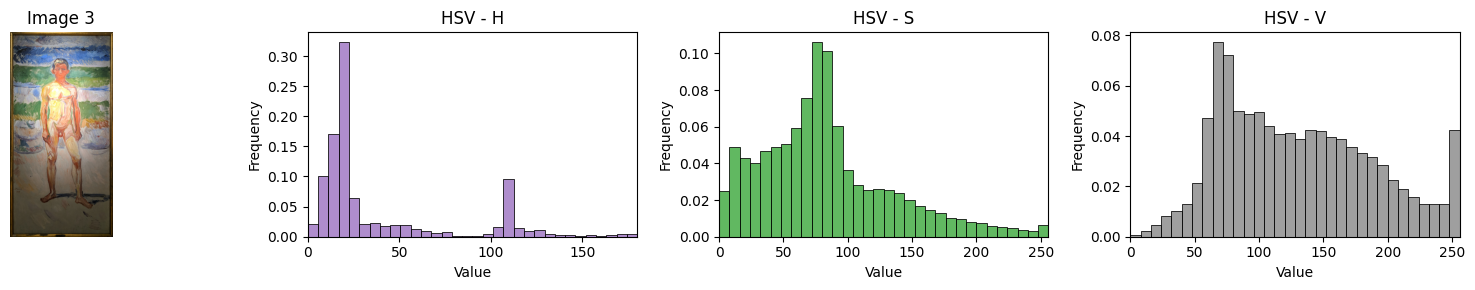

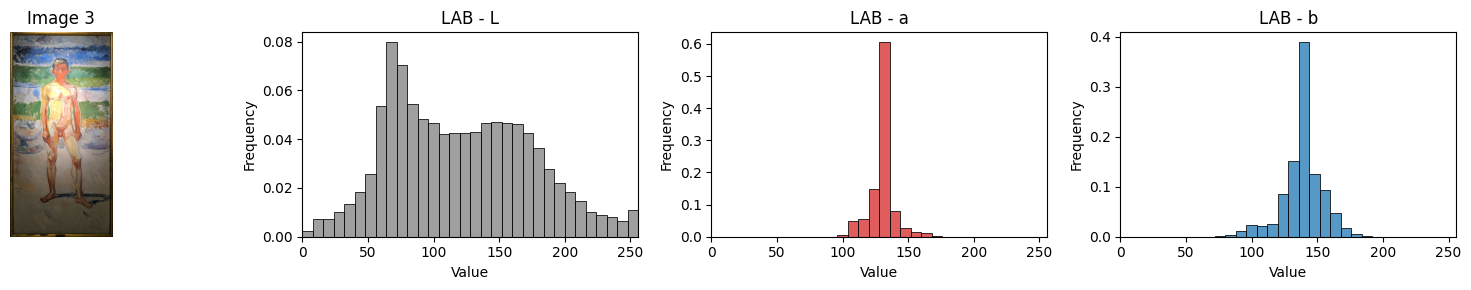

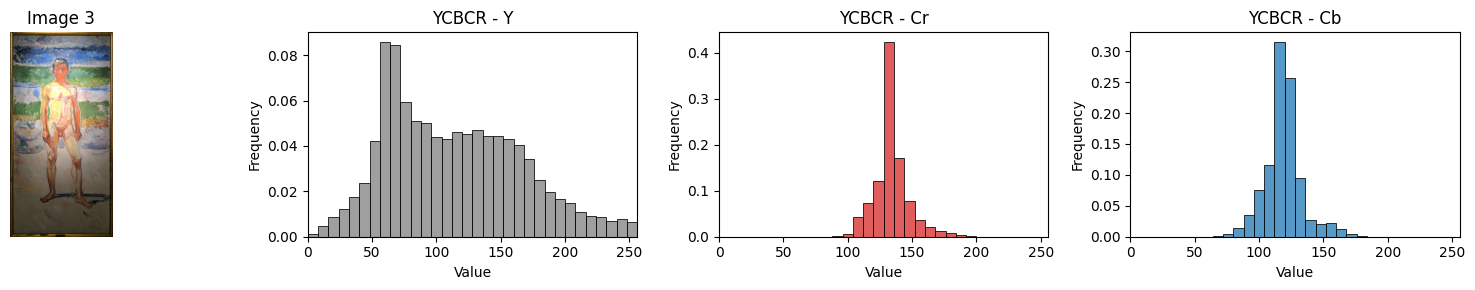

In [10]:
plot_image_histograms(df_bbdd.iloc[3], color_space="hsv", bins=32)
plot_image_histograms(df_bbdd.iloc[3], color_space="lab", bins=32)
plot_image_histograms(df_bbdd.iloc[3], color_space="ycbcr", bins=32)

## Distances

In [11]:
SIMILARITIES = {"intersection", "hellinger"}   # higher = more similar
DISTANCES = {"euclidean", "l1", "x2", "chi_squared", "emd", "bhattacharyya"}  # lower = more similar



def _emd(h1, h2, color_space, n_channels=3, use_cv2=False):
    """
    Earth Mover's Distance, computed per channel and summed.
    For 1D histograms EMD has a closed form (L1 distance between CDFs).
    That is identical to cv2.EMD and much faster. Set use_cv2=True to use cv2.EMD.
    """
    sizes = [high - low for low, high in COLOR_SPACES[color_space][1]] 
    splits = np.cumsum(sizes)[:-1]

    total = 0.0
    for x, y in zip(np.split(h1, splits), np.split(h2, splits)):
        x = x / (x.sum() + EPS)
        y = y / (y.sum() + EPS)
        total += np.abs(np.cumsum(x) - np.cumsum(y)).sum()
    return float(total)


def compare_histograms(h1, h2, distance, color_space):
    h1 = np.asarray(h1, dtype=np.float32).ravel()
    h2 = np.asarray(h2, dtype=np.float32).ravel()

    if distance == "euclidean":
        return cv2.norm(h1, h2, cv2.NORM_L2)
    if distance == "l1":
        return cv2.norm(h1, h2, cv2.NORM_L1)
    if distance == "x2":
        # Symmetric X2: 2 * sum (h1-h2)^2 / (h1+h2)
        return cv2.compareHist(h1, h2, cv2.HISTCMP_CHISQR_ALT)
    if distance == "chi_squared":
        # Classic (Pearson) chi-squared: sum (h1-h2)^2 / h1
        return cv2.compareHist(h1, h2, cv2.HISTCMP_CHISQR)
    if distance == "intersection":
        # sum min(h1, h2)  -> similarity in [0, 1]
        return cv2.compareHist(h1, h2, cv2.HISTCMP_INTERSECT)
    if distance == "hellinger":
        # Hellinger kernel: sum sqrt(h1 * h2) -> similarity in [0, 1]
        return float(np.sum(np.sqrt(h1 * h2)))
    if distance == "emd":
        return _emd(h1, h2, color_space)
    if distance == "bhattacharyya":
        # Classic Bhattacharyya distance: -ln( sum sqrt(h1 * h2) )
        return float(-np.log(np.sum(np.sqrt(h1 * h2)) + EPS))

    raise ValueError(f"Unknown distance '{distance}'. Options: {sorted(SIMILARITIES | DISTANCES)}")

In [12]:
def get_similar(image, dataset, k, descriptor, distance, plot=False):

    # convert the image to histogram
    query_hist = compute_histogram(image["image_path"], descriptor)

    # compute the distance/similarity against every image of the dataset
    scores = dataset[f"hist_{descriptor}"].apply(lambda h: compare_histograms(query_hist, h, distance, descriptor))

    # get the top k most similar images (similarities: descending, distances: ascending)
    ascending = distance not in SIMILARITIES
    top_k = dataset.assign(score=scores).sort_values("score", ascending=ascending).head(k)

    # calculate the AP@k (the mean over all queries is the mAP@k)
    gt = image["ground_truth"]
    gt = list(gt) if isinstance(gt, (list, tuple, np.ndarray)) else [gt]

    hits, score = 0, 0.0
    for i, pred in enumerate(top_k["image_name"]):
        if pred in gt:
            hits += 1
            score += hits / (i + 1)

    ap = score / min(len(gt), k)

    # plot the original image and the k most similar ones with their score
    if plot:
        fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3.5))
        axes[0].imshow(cv2.cvtColor(cv2.imread(image["image_path"]), cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Query {image['image_name']}\nAP@{k} = {ap:.2f}")

        for ax, (_, row) in zip(axes[1:], top_k.iterrows()):
            ax.imshow(cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB))
            correct = row["image_name"] in gt
            ax.set_title(f"{row['image_name']:05d}\n {distance}: {row['score']:.3f}",
                         color="green" if correct else "red")

        for ax in axes:
            ax.axis("off")
        fig.suptitle(f"{descriptor.upper()} histogram - {distance}")
        fig.tight_layout()
        plt.show()

    return top_k["score"].to_dict(), ap


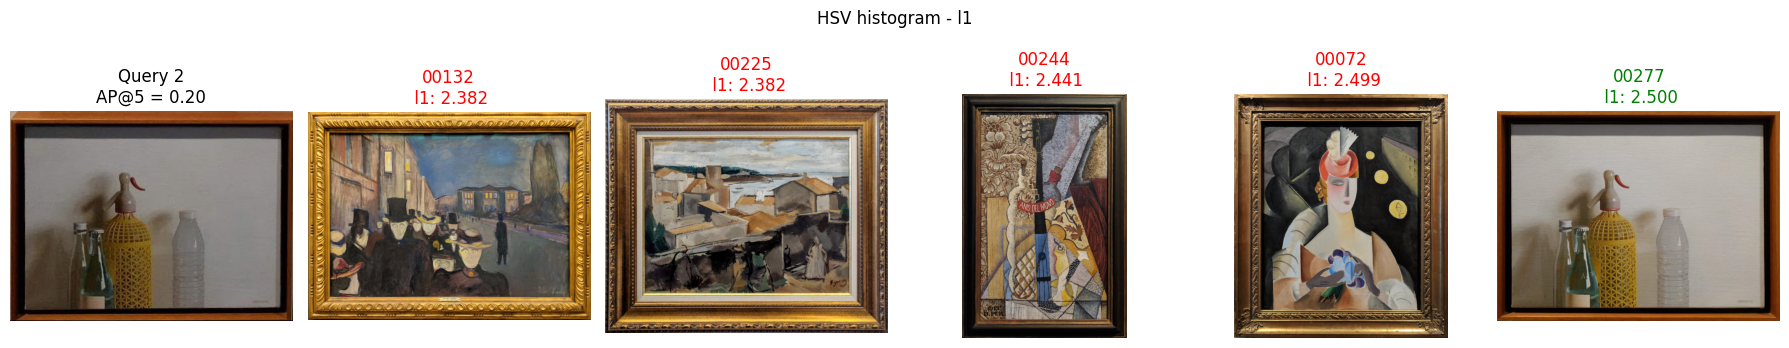

({132: 2.3815541246584075,
  225: 2.381723575731314,
  244: 2.4411232443735003,
  72: 2.498781587787761,
  277: 2.4997520884676305},
 0.2)

In [13]:
get_similar(df_qsd1_w1.iloc[2], df_bbdd, 5, 'hsv', 'l1', 'true')

In [19]:
# Grid search: iterate over every image in df_qsd1_w1, every distance and every k
def grid_search(descriptor):
    results = []

    for k in range(1, 6):
        for distance in sorted(SIMILARITIES | DISTANCES):
            for _, test_img in df_qsd1_w1.iterrows():
                _, ap = get_similar(test_img, df_bbdd, k, descriptor, distance)
                results.append({
                    "k": k,
                    "distance": distance,
                    "image_name": test_img["image_name"],
                    "ap": ap,
                })

    # Save the results
    df_results = pd.DataFrame(results)

    # Mean AP (mAP@k) for each distance and k
    df_map = df_results.groupby(["distance", "k"])["ap"].mean().unstack("k")
    df_map = df_map.sort_values(df_map.columns[-1], ascending=False)  # best distance first
    print(df_map.round(3))

    best_distance, best_k = df_map.stack().idxmax()
    print(f"Best: {best_distance} with k={best_k} -> mAP@k = {df_map.loc[best_distance, best_k]:.3f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(df_map, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1, ax=axes[0])
    axes[0].set(title=f"mAP@k - {descriptor.upper()}", xlabel="k", ylabel="Distance")

    sns.lineplot(data=df_results, x="k", y="ap", hue="distance", marker="o", errorbar=None, ax=axes[1])
    axes[1].set(title=f"mAP@k by distance - {descriptor.upper()}", xlabel="k", ylabel="mAP@k", ylim=(0, 1))
    axes[1].set_xticks(range(1, 6))
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.tight_layout()
    plt.show()

    return df_map 

k                  1      2      3      4      5
distance                                        
l1             0.433  0.483  0.517  0.525  0.525
intersection   0.433  0.483  0.517  0.525  0.525
bhattacharyya  0.433  0.467  0.489  0.506  0.512
hellinger      0.433  0.467  0.489  0.506  0.512
x2             0.433  0.450  0.483  0.492  0.498
emd            0.400  0.417  0.417  0.458  0.465
chi_squared    0.300  0.317  0.317  0.317  0.330
euclidean      0.267  0.283  0.283  0.300  0.307
Best: l1 with k=4 -> mAP@k = 0.525


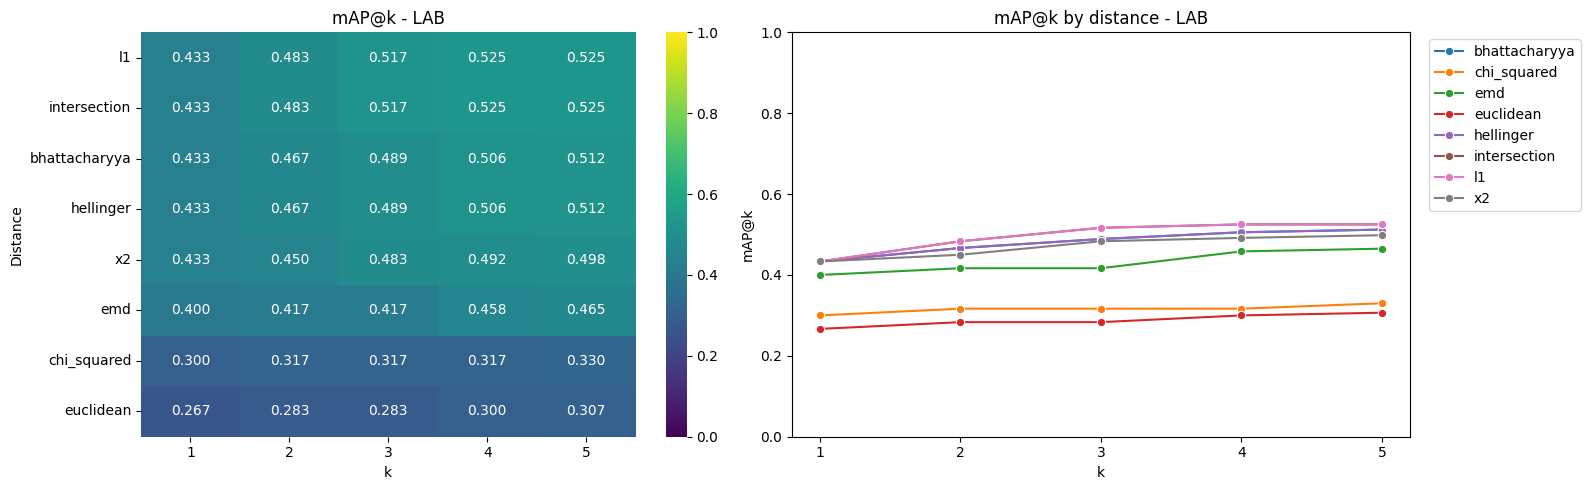

In [20]:
lab_results = grid_search('lab')

k                  1      2      3      4      5
distance                                        
emd            0.400  0.417  0.439  0.464  0.471
intersection   0.333  0.383  0.406  0.422  0.429
l1             0.333  0.383  0.406  0.422  0.429
x2             0.333  0.333  0.344  0.378  0.384
bhattacharyya  0.333  0.350  0.350  0.375  0.382
hellinger      0.333  0.350  0.350  0.375  0.382
euclidean      0.267  0.283  0.283  0.283  0.283
chi_squared    0.233  0.250  0.261  0.261  0.268
Best: emd with k=5 -> mAP@k = 0.471


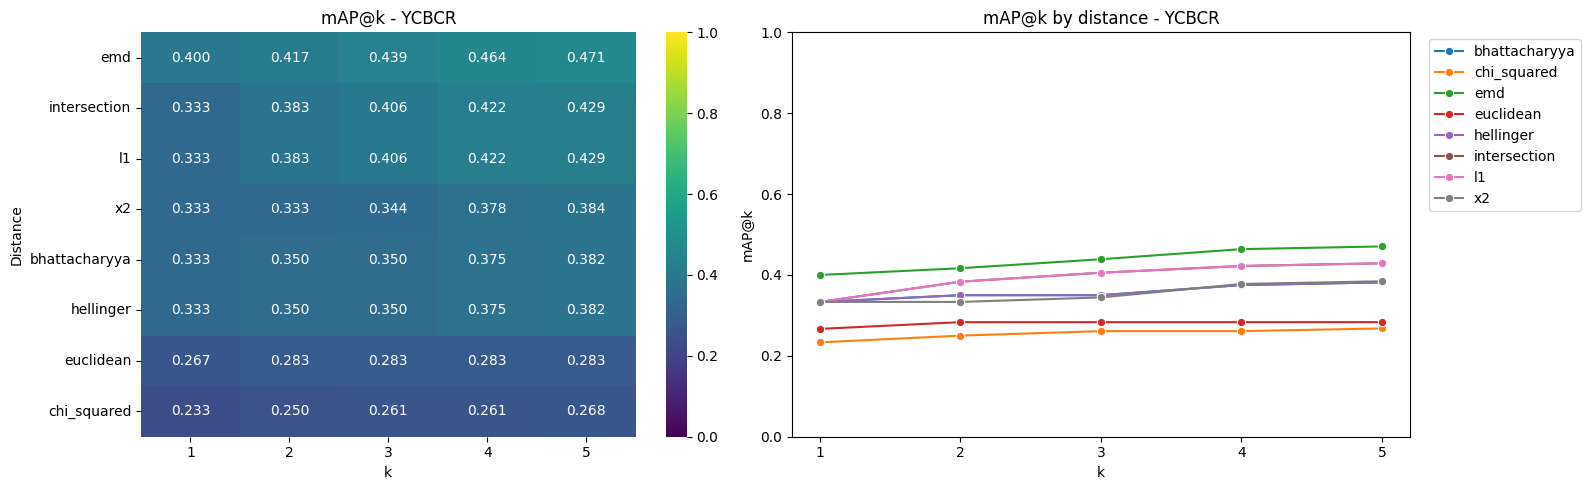

In [21]:
ycbcr_restults = grid_search('ycbcr')

k                  1      2      3      4      5
distance                                        
emd            0.433  0.483  0.517  0.517  0.530
intersection   0.367  0.417  0.439  0.456  0.469
l1             0.367  0.417  0.439  0.456  0.469
x2             0.400  0.417  0.417  0.450  0.457
bhattacharyya  0.400  0.417  0.428  0.444  0.451
hellinger      0.400  0.417  0.428  0.444  0.451
euclidean      0.267  0.317  0.317  0.325  0.325
chi_squared    0.233  0.250  0.294  0.294  0.294
Best: emd with k=5 -> mAP@k = 0.530


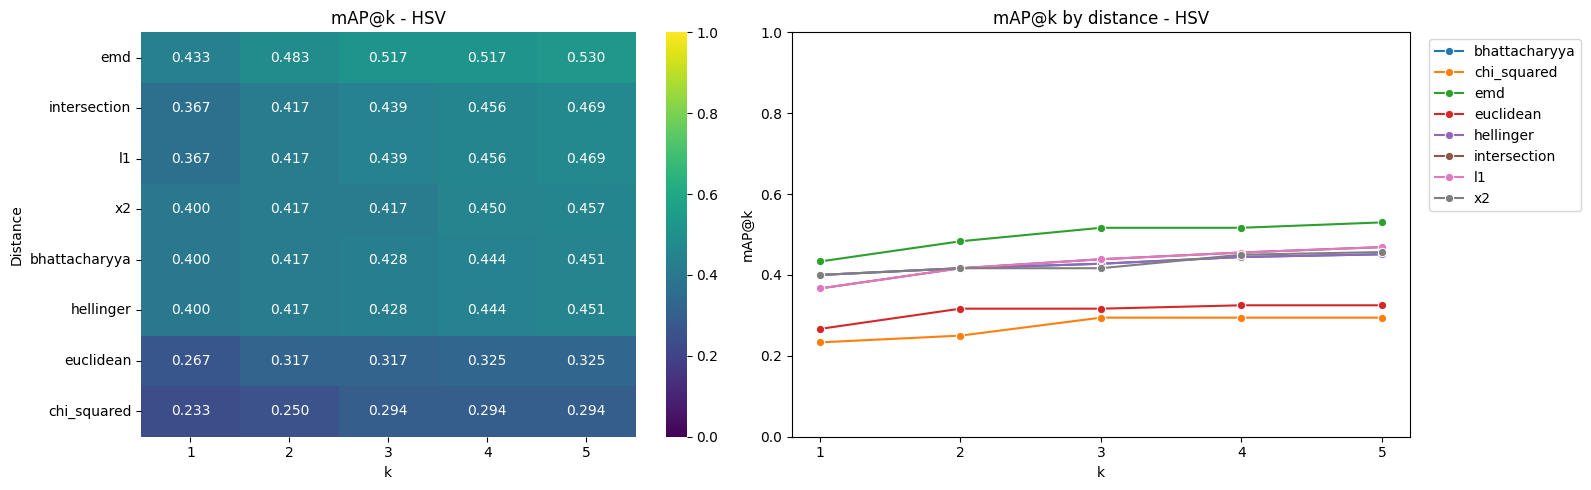

In [22]:
hsv_results = grid_search('hsv')

# Comparation

In [ ]:
lab_results

# i want to turn this table into this columns to channel, metric (being the distance), mAP@1, mAP@5

k,1,2,3,4,5
distance,,,,,
l1,0.433333,0.483333,0.516667,0.525000,0.525000
intersection,0.433333,0.483333,0.516667,0.525000,0.525000
bhattacharyya,0.433333,0.466667,0.488889,0.505556,0.512222
hellinger,0.433333,0.466667,0.488889,0.505556,0.512222
x2,0.433333,0.450000,0.483333,0.491667,0.498333
emd,0.400000,0.416667,0.416667,0.458333,0.465000
chi_squared,0.300000,0.316667,0.316667,0.316667,0.330000
euclidean,0.266667,0.283333,0.283333,0.300000,0.306667


In [25]:
lab_summary = (
        lab_results[[1, 5]]
        .rename(columns={1: "mAP@1", 5: "mAP@5"})
        .rename_axis(columns=None)
        .reset_index()
        .rename(columns={"distance": "metric"}))
lab_summary.insert(0, "channel", 'lab')

hsv_summary = (
        hsv_results[[1, 5]]
        .rename(columns={1: "mAP@1", 5: "mAP@5"})
        .rename_axis(columns=None)
        .reset_index()
        .rename(columns={"distance": "metric"}))
hsv_summary.insert(0, "channel", 'hsv')

ycbcr_summary = (
        ycbcr_restults[[1, 5]]
        .rename(columns={1: "mAP@1", 5: "mAP@5"})
        .rename_axis(columns=None)
        .reset_index()
        .rename(columns={"distance": "metric"}))
ycbcr_summary.insert(0, "channel", 'ycbcr')



df_all = pd.concat([lab_summary, hsv_summary, ycbcr_summary], ignore_index=True).sort_values("mAP@5", ascending=False)
df_all

,channel,metric,mAP@1,mAP@5
8,hsv,emd,0.433333,0.530000
0,lab,l1,0.433333,0.525000
1,lab,intersection,0.433333,0.525000
2,lab,bhattacharyya,0.433333,0.512222
3,lab,hellinger,0.433333,0.512222
4,lab,x2,0.433333,0.498333
16,ycbcr,emd,0.400000,0.470556
10,hsv,l1,0.366667,0.468889
9,hsv,intersection,0.366667,0.468889
5,lab,emd,0.400000,0.465000
